# Matplotlib 风格和美化

本笔记本演示 Matplotlib 的图表美化技术，包括颜色、样式、标签等。

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

## 1. Matplotlib 风格（Styles）

In [3]:
# 查看可用风格
print("可用风格:")
print(plt.style.available)

可用风格:
['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


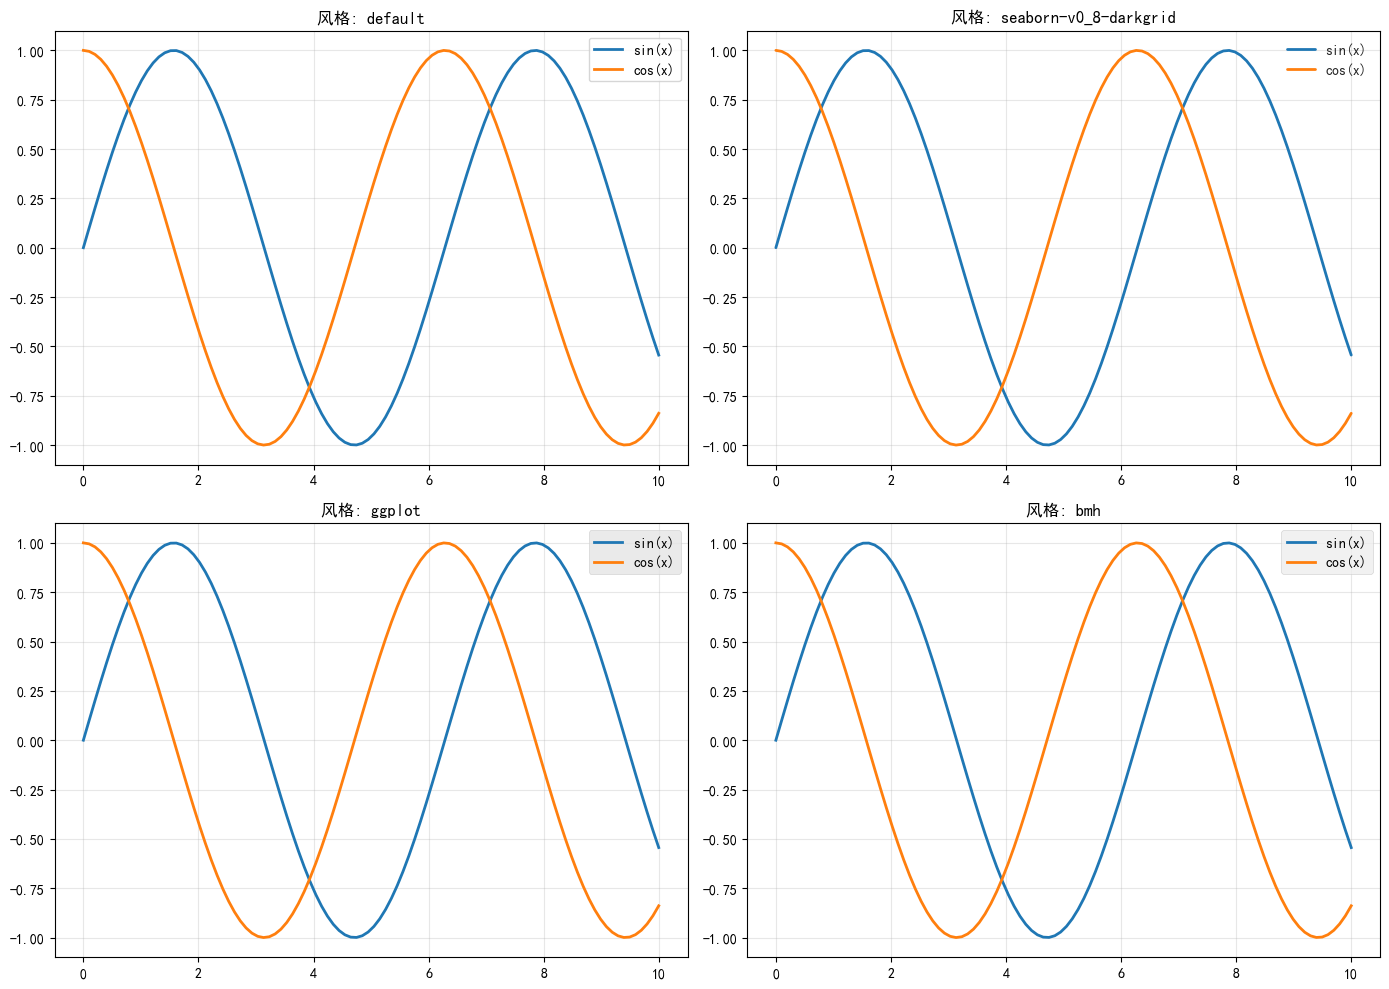

In [4]:
# 应用不同风格
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

styles = ['default', 'seaborn-v0_8-darkgrid', 'ggplot', 'bmh']
x = np.linspace(0, 10, 100)

for idx, (ax, style) in enumerate(zip(axes.flatten(), styles)):
    with plt.style.context(style):
        ax.plot(x, np.sin(x), linewidth=2, label='sin(x)')
        ax.plot(x, np.cos(x), linewidth=2, label='cos(x)')
        ax.set_title(f'风格: {style}', fontsize=12, fontweight='bold')
        ax.legend()
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. 颜色和调色板

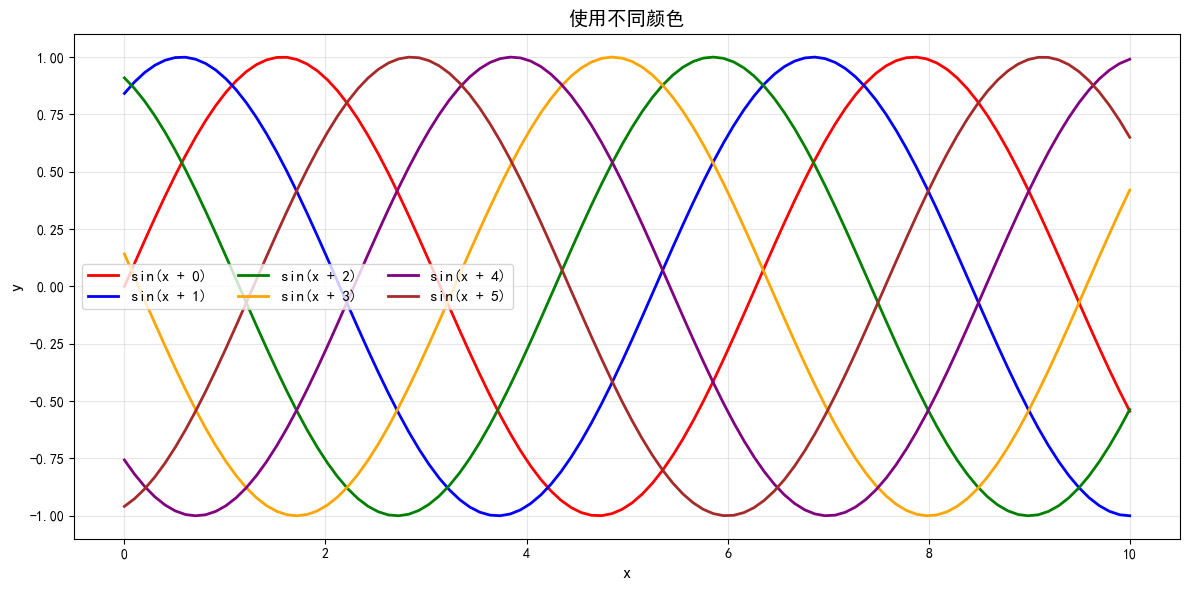

In [5]:
# 使用不同颜色
fig, ax = plt.subplots(figsize=(12, 6))

x = np.linspace(0, 10, 100)
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown']

for i, color in enumerate(colors):
    ax.plot(x, np.sin(x + i), linewidth=2, label=f'sin(x + {i})', color=color)

ax.set_title('使用不同颜色', fontsize=14, fontweight='bold')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11, ncol=3)

plt.tight_layout()
plt.show()

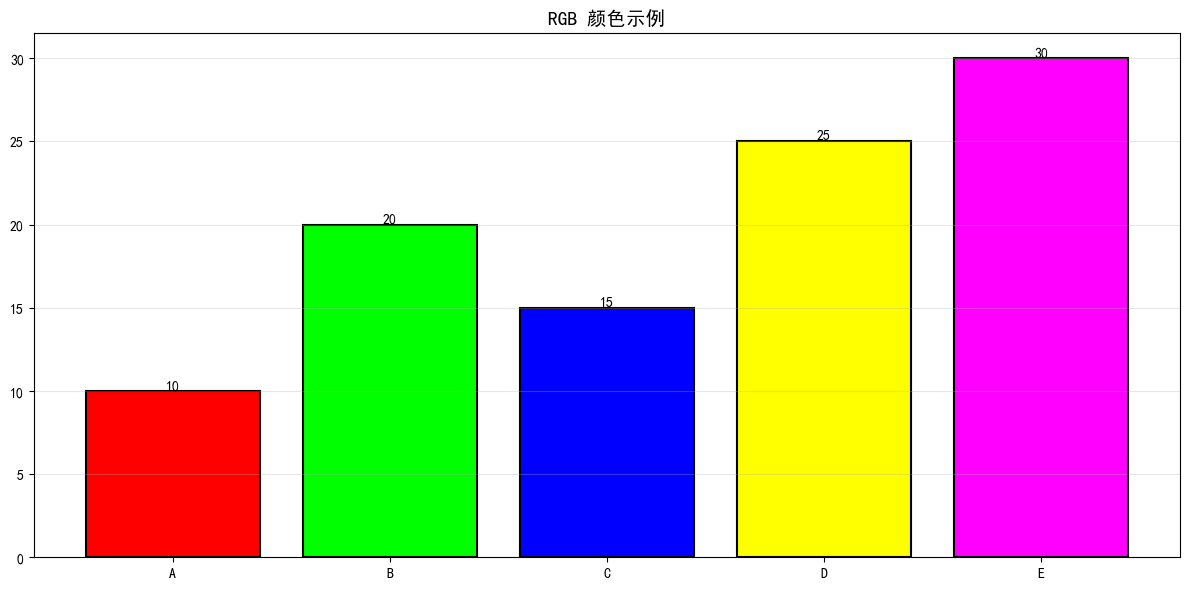

In [6]:
# RGB 和 HEX 颜色
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(5)
y = [10, 20, 15, 25, 30]

# RGB 颜色（0-1 范围）
colors_rgb = [(1, 0, 0), (0, 1, 0), (0, 0, 1), (1, 1, 0), (1, 0, 1)]
bars = ax.bar(x, y, color=colors_rgb, edgecolor='black', linewidth=1.5)

# 添加值标签
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=10)

ax.set_title('RGB 颜色示例', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(['A', 'B', 'C', 'D', 'E'])
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

C:\Users\zhang\AppData\Local\Temp\ipykernel_19448\1979770594.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


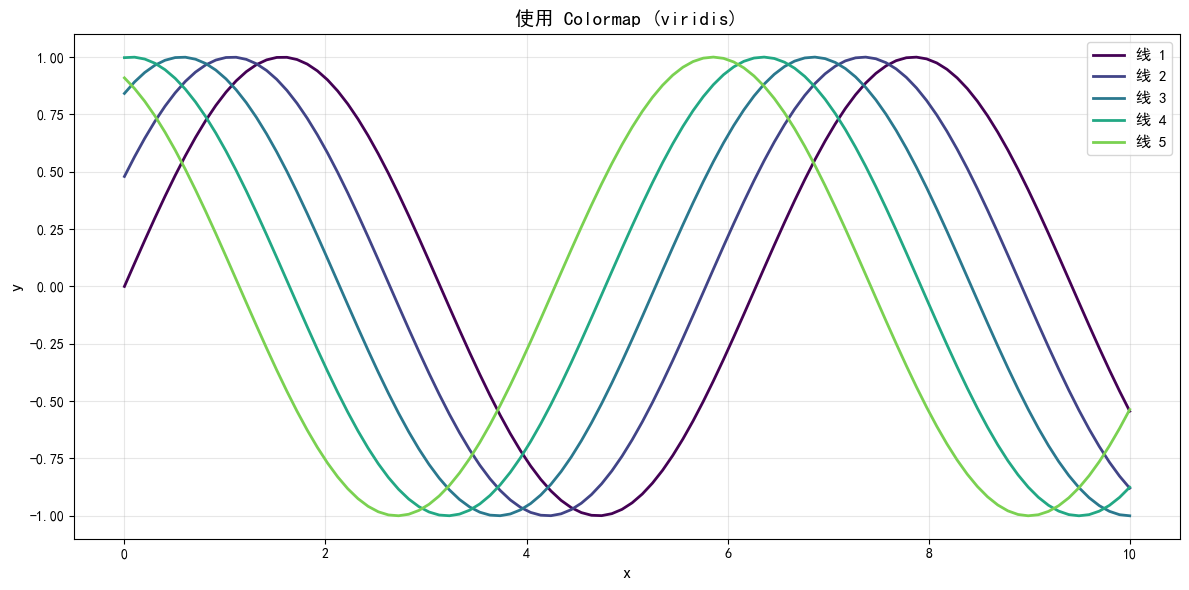

In [7]:
# 使用 colormap
fig, ax = plt.subplots(figsize=(12, 6))

x = np.linspace(0, 10, 100)
cmap = plt.cm.get_cmap('viridis')

# 创建不同颜色的线
for i in range(5):
    y = np.sin(x + i * 0.5)
    color = cmap(i / 5)
    ax.plot(x, y, linewidth=2, color=color, label=f'线 {i+1}')

ax.set_title('使用 Colormap (viridis)', fontsize=14, fontweight='bold')
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

## 3. 标签、标题和注释

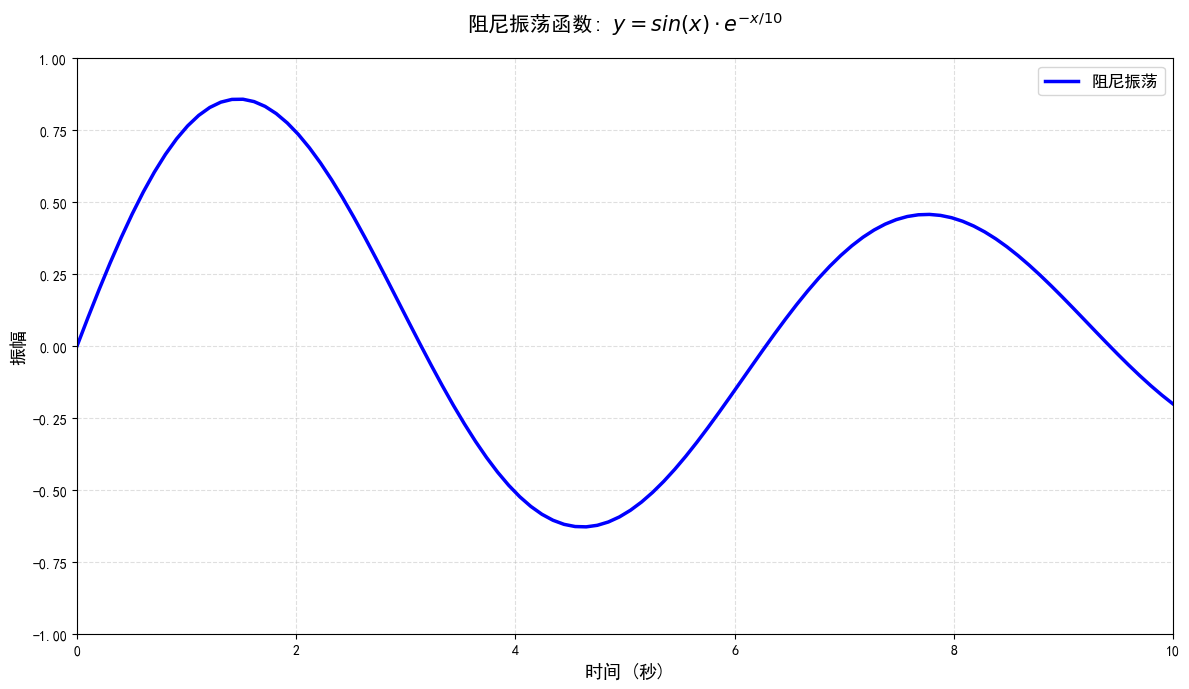

In [8]:
# 详细的标签和标题设置
fig, ax = plt.subplots(figsize=(12, 7))

x = np.linspace(0, 10, 100)
y = np.sin(x) * np.exp(-x/10)

ax.plot(x, y, 'b-', linewidth=2.5, label='阻尼振荡')

# 详细的标签设置
ax.set_xlabel('时间 (秒)', fontsize=13, fontweight='bold')
ax.set_ylabel('振幅', fontsize=13, fontweight='bold')

# 标题设置
ax.set_title('阻尼振荡函数: $y = sin(x) \\cdot e^{-x/10}$',
             fontsize=15, fontweight='bold', pad=20)

# 添加网格
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)

# 添加图例
ax.legend(fontsize=12, loc='upper right')

# 设置坐标轴范围
ax.set_xlim(0, 10)
ax.set_ylim(-1, 1)

plt.tight_layout()
plt.show()

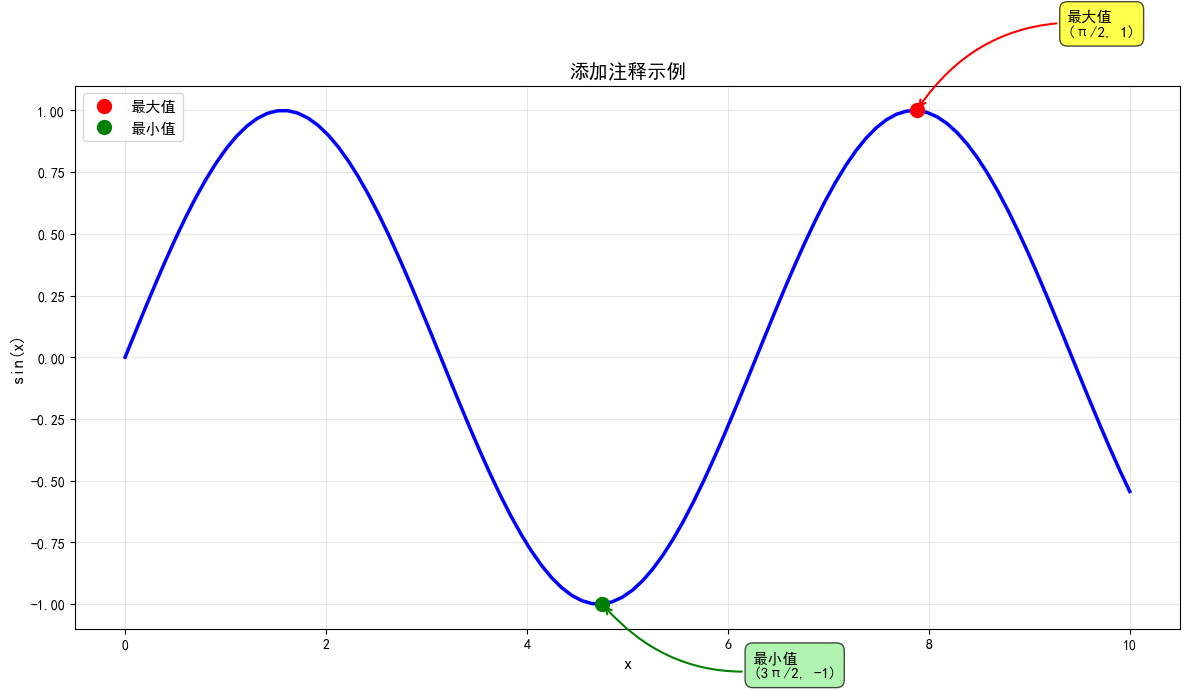

In [9]:
# 添加注释（Annotations）
fig, ax = plt.subplots(figsize=(12, 7))

x = np.linspace(0, 10, 100)
y = np.sin(x)

ax.plot(x, y, 'b-', linewidth=2.5)

# 标记最大值
max_idx = np.argmax(y)
ax.plot(x[max_idx], y[max_idx], 'ro', markersize=10, label='最大值')
ax.annotate('最大值\n(π/2, 1)',
            xy=(x[max_idx], y[max_idx]),
            xytext=(x[max_idx] + 1.5, y[max_idx] + 0.3),
            fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.3',
                           color='red', lw=1.5))

# 标记最小值
min_idx = np.argmin(y)
ax.plot(x[min_idx], y[min_idx], 'go', markersize=10, label='最小值')
ax.annotate('最小值\n(3π/2, -1)',
            xy=(x[min_idx], y[min_idx]),
            xytext=(x[min_idx] + 1.5, y[min_idx] - 0.3),
            fontsize=11,
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=-0.3',
                           color='green', lw=1.5))

ax.set_xlabel('x', fontsize=12, fontweight='bold')
ax.set_ylabel('sin(x)', fontsize=12, fontweight='bold')
ax.set_title('添加注释示例', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

## 4. 填充和透明度

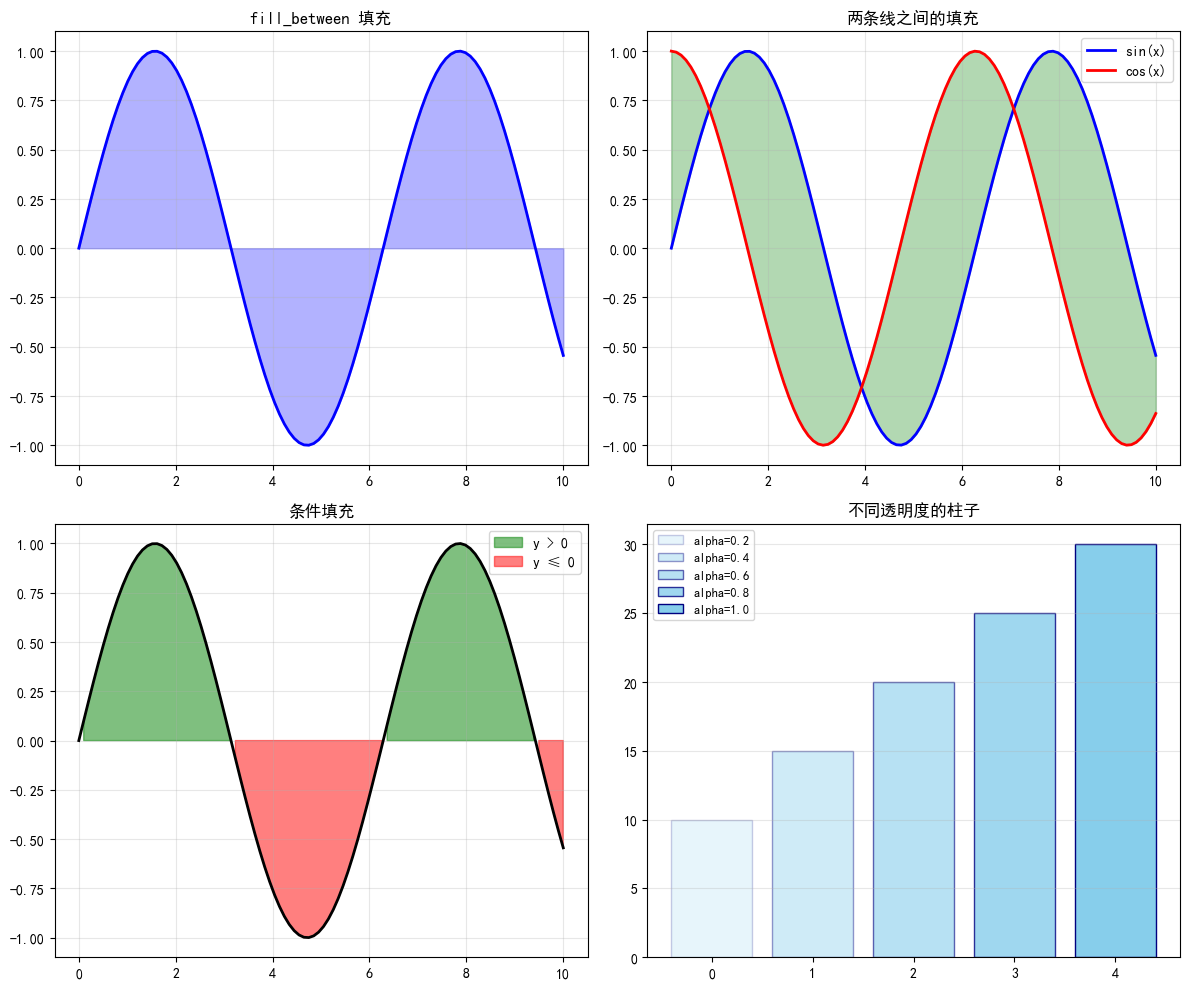

In [10]:
# 填充区域
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

x = np.linspace(0, 10, 100)

# 填充单一区域
ax = axes[0, 0]
y = np.sin(x)
ax.fill_between(x, y, alpha=0.3, color='blue')
ax.plot(x, y, color='blue', linewidth=2)
ax.set_title('fill_between 填充', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)

# 填充两条线之间的区域
ax = axes[0, 1]
y1 = np.sin(x)
y2 = np.cos(x)
ax.fill_between(x, y1, y2, alpha=0.3, color='green')
ax.plot(x, y1, color='blue', linewidth=2, label='sin(x)')
ax.plot(x, y2, color='red', linewidth=2, label='cos(x)')
ax.set_title('两条线之间的填充', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# 条件填充
ax = axes[1, 0]
y = np.sin(x)
ax.fill_between(x, y, where=(y > 0), alpha=0.5, color='green', label='y > 0')
ax.fill_between(x, y, where=(y <= 0), alpha=0.5, color='red', label='y ≤ 0')
ax.plot(x, y, color='black', linewidth=2)
ax.set_title('条件填充', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend()

# 透明度调整
ax = axes[1, 1]
for i in range(5):
    alpha = (i + 1) / 5
    ax.bar(i, 10 + i*5, alpha=alpha, color='skyblue', edgecolor='navy',
           label=f'alpha={alpha:.1f}')
ax.set_title('不同透明度的柱子', fontsize=12, fontweight='bold')
ax.set_xticks(range(5))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 5. 字体和文本设置

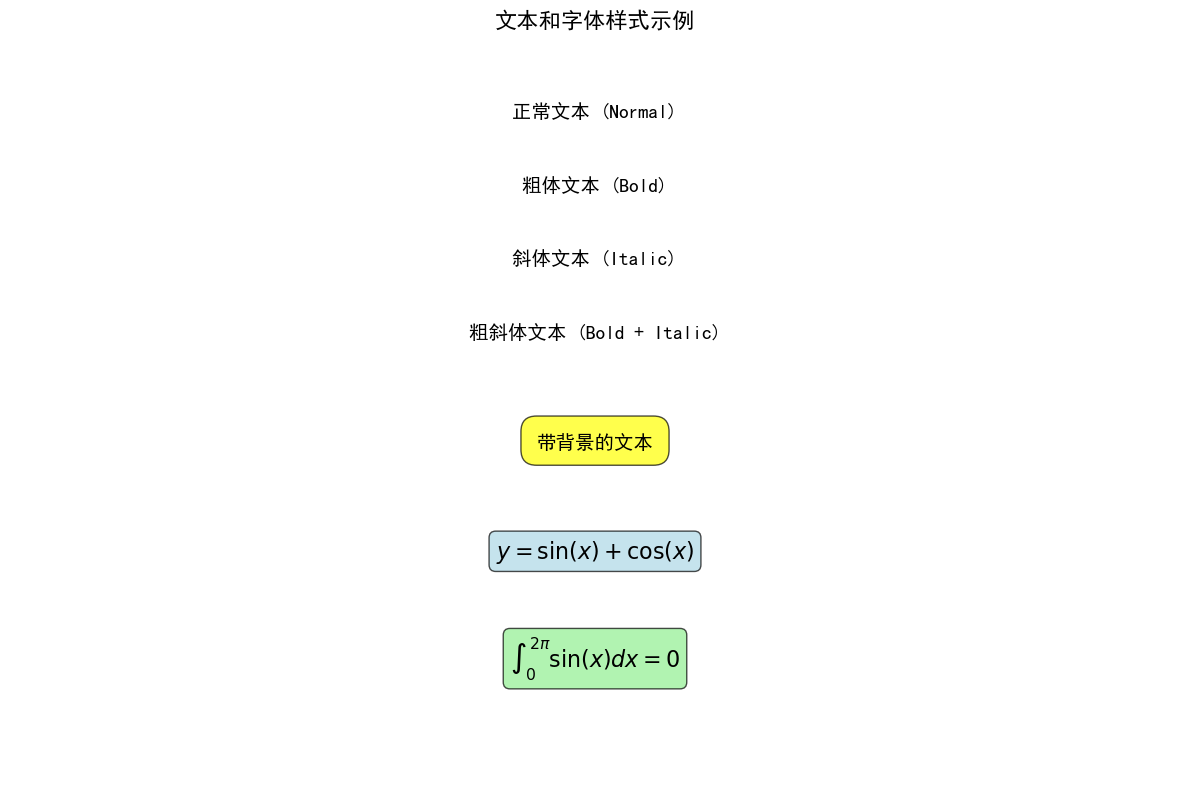

In [11]:
# 字体和文本样式
fig, ax = plt.subplots(figsize=(12, 8))

# 添加不同样式的文本
ax.text(0.5, 0.9, '正常文本 (Normal)', fontsize=14, ha='center',
        transform=ax.transAxes)
ax.text(0.5, 0.8, '粗体文本 (Bold)', fontsize=14, fontweight='bold', ha='center',
        transform=ax.transAxes)
ax.text(0.5, 0.7, '斜体文本 (Italic)', fontsize=14, fontstyle='italic', ha='center',
        transform=ax.transAxes)
ax.text(0.5, 0.6, '粗斜体文本 (Bold + Italic)', fontsize=14,
        fontweight='bold', fontstyle='italic', ha='center',
        transform=ax.transAxes)

# 添加带背景的文本
ax.text(0.5, 0.45, '带背景的文本', fontsize=14, ha='center',
        bbox=dict(boxstyle='round,pad=0.8', facecolor='yellow', alpha=0.7),
        transform=ax.transAxes)

# 数学公式文本
ax.text(0.5, 0.3, r'$y = \sin(x) + \cos(x)$', fontsize=16, ha='center',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7),
        transform=ax.transAxes)

# 添加 LaTeX 公式
ax.text(0.5, 0.15, r'$\int_0^{2\pi} \sin(x) dx = 0$', fontsize=16, ha='center',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.7),
        transform=ax.transAxes)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')  # 隐藏坐标轴

fig.suptitle('文本和字体样式示例', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()